Loading data...
Building and training the model...
Epoch 1/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9018 - loss: 0.3250 - val_accuracy: 0.9772 - val_loss: 0.0742
Epoch 2/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9675 - loss: 0.1088 - val_accuracy: 0.9862 - val_loss: 0.0447
Calculating SHAP values...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_36
Received: inputs=['Tensor(shape=(1, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_36
Received: inputs=['Tensor(shape=(50, 28, 28, 1))']
  warnings.warn(msg)


Calculating LIME values...


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating visualization...


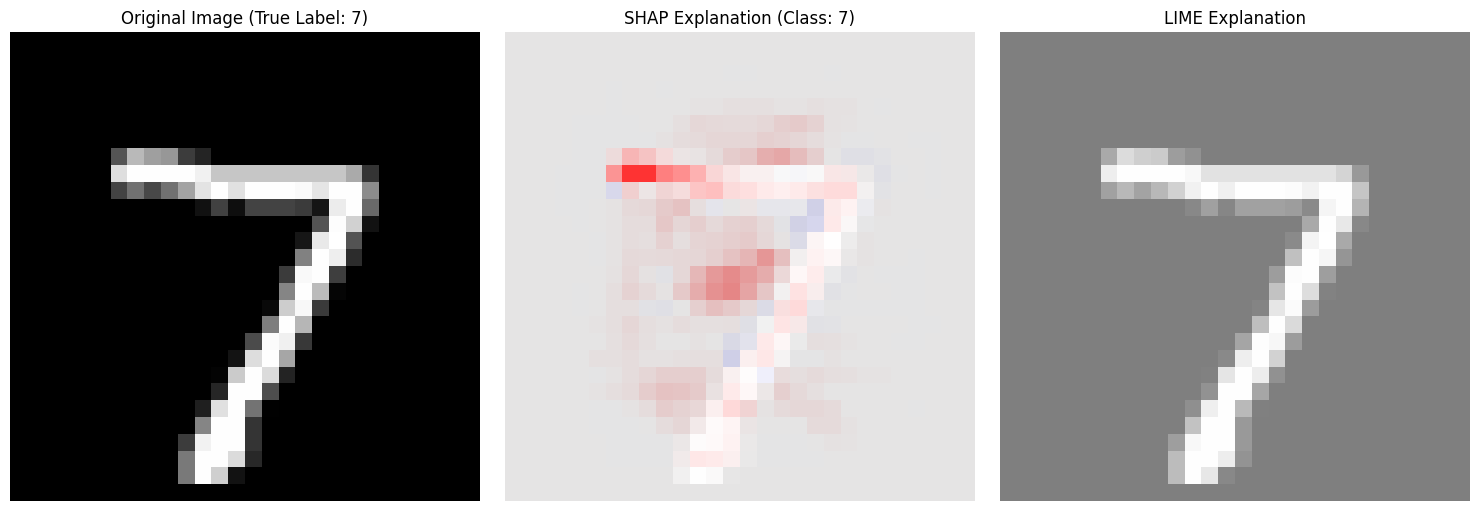

In [ ]:

# ---------------------------------------------------------
!pip install shap lime tensorflow scikit-image matplotlib numpy

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt


print("Loading data...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Reshape for CNN (samples, height, width, channels) and normalize
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# ---------------------------------------------------------
# STEP 2: Build and Train the Target CNN
# ---------------------------------------------------------
print("Building and training the model...")
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

# Training for just 2 epochs to keep execution fast for the project
model.fit(x_train, y_train, batch_size=128, epochs=2, validation_split=0.1)

# ---------------------------------------------------------
# STEP 3: Implement SHAP (GradientExplainer)
# ---------------------------------------------------------
print("Calculating SHAP values...")
# Use 100 random background images to establish the baseline
background = x_train[np.random.choice(x_train.shape[0], 100, replace=False)]
# Swapping DeepExplainer for GradientExplainer as recommended for TF 2.x
shap_explainer = shap.GradientExplainer(model, background)

# Select a single image to explain for our side-by-side comparison
image_index = 0  # This is usually a '7' in the test set
test_image = x_test[image_index:image_index+1]
true_label = y_test[image_index]

# Get SHAP values
shap_values = shap_explainer.shap_values(test_image)

# ---------------------------------------------------------
# STEP 4: Implement LIME (Local Interpretable Model-agnostic Explanations)
# ---------------------------------------------------------
print("Calculating LIME values...")
lime_explainer = lime_image.LimeImageExplainer()

# LIME expects 3-channel (RGB) images to perturb them properly.
# We create a wrapper function so LIME can feed RGB images in,
# and the CNN can pull out just the grayscale channel it expects.
def predict_fn(images):
    # Convert LIME's RGB perturbations back to Grayscale (1 channel)
    gray_images = images[:, :, :, 0:1]
    return model.predict(gray_images, verbose=0)

# Convert our test image to 3 channels just for LIME's internal processing
test_image_rgb = np.repeat(test_image[0], 3, axis=-1)

# Generate the LIME explanation
lime_exp = lime_explainer.explain_instance(
    test_image_rgb,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000 # Number of perturbations to test
)

# Extract the image and mask for the top predicted class
temp, mask = lime_exp.get_image_and_mask(lime_exp.top_labels[0], positive_only=True, num_features=5, hide_rest=True)

# ---------------------------------------------------------
# STEP 5: Visualize the Comparison (UPDATED)
# ---------------------------------------------------------
print("Generating visualization...")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Original Image
axes[0].imshow(test_image[0, :, :, 0], cmap='gray')
axes[0].set_title(f"Original Image (True Label: {true_label})")
axes[0].axis('off')

# Plot 2: SHAP Explanation
predicted_class = np.argmax(model.predict(test_image, verbose=0))

# --- NEW ROBUST ARRAY HANDLING ---
if isinstance(shap_values, list):
    # Older SHAP versions: list of arrays
    shap_to_plot = shap_values[predicted_class][0, :, :, 0]
else:
    # Newer SHAP versions: single array (samples, height, width, channels, classes)
    shap_to_plot = shap_values[0, :, :, 0, predicted_class]
# ---------------------------------

max_val = np.max(np.abs(shap_to_plot))
axes[1].imshow(test_image[0, :, :, 0], cmap='gray', alpha=0.5)
im = axes[1].imshow(shap_to_plot, cmap='bwr', vmin=-max_val, vmax=max_val, alpha=0.8)
axes[1].set_title(f"SHAP Explanation (Class: {predicted_class})")
axes[1].axis('off')

# Plot 3: LIME Explanation
axes[2].imshow(mark_boundaries(temp / 2 + 0.5, mask))
axes[2].set_title("LIME Explanation")
axes[2].axis('off')

plt.tight_layout()
plt.show()